# 01 — Linear regression from scratch

The simplest model worth studying, and the one every later chapter is built on.
We derive it twice: once with calculus (closed form), once with an algorithm
(gradient descent). Getting the same answer both ways is the point.

**Model.** $\hat{y} = Xw + b$

**Loss.** Mean squared error, $L(w) = \frac{1}{n}\sum_i (\hat{y}_i - y_i)^2$

**Why squared error?** It is differentiable everywhere (unlike absolute error at
zero), it penalises large mistakes disproportionately, and it happens to be the
maximum-likelihood estimator under Gaussian noise.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

## Generate data where we know the answer

Testing on synthetic data with known coefficients is the fastest way to catch a
broken implementation. If we cannot recover `true_w`, something is wrong.

X: (200, 1)  y: (200,)
target: w = 2.5, b = 1.0


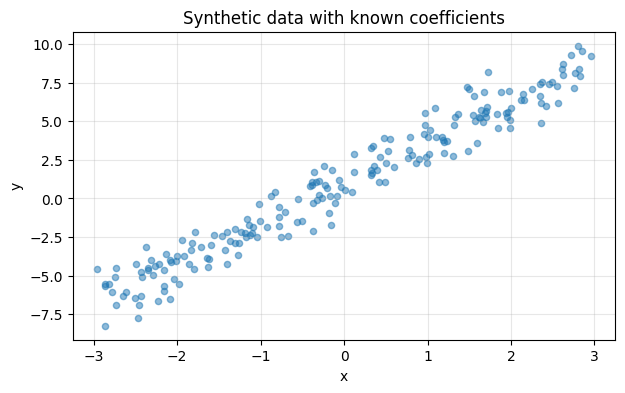

In [2]:
n_samples, n_features = 200, 1
true_w = np.array([2.5])
true_b = 1.0

X = rng.uniform(-3, 3, size=(n_samples, n_features))
noise = rng.normal(0, 1.0, size=n_samples)
y = X @ true_w + true_b + noise

print("X:", X.shape, " y:", y.shape)
print(f"target: w = {true_w[0]}, b = {true_b}")

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.5, s=20)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Synthetic data with known coefficients")
plt.grid(alpha=0.3); plt.show()

## The bias trick

Rather than carrying `b` as a separate term, prepend a column of ones to `X`.
Then `b` is just `theta[0]` — one weight vector, one gradient, less code.

In [3]:
def add_bias(X):
    """Prepend a column of ones so the intercept becomes weight zero."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

Xb = add_bias(X)
print("X:", X.shape, "->  Xb:", Xb.shape)
print(Xb[:3])

X: (200, 1) ->  Xb: (200, 2)
[[ 1.     1.644]
 [ 1.    -0.367]
 [ 1.     2.152]]


## Solution 1 — the normal equation

Set the gradient to zero and solve. For MSE the loss is convex and quadratic, so
there is exactly one stationary point and it is the global minimum:

$$\theta = (X^\top X)^{-1} X^\top y$$

We use `pinv` rather than `inv`: if features are collinear, $X^\top X$ is singular
and `inv` throws. The pseudo-inverse returns the minimum-norm solution instead.

In [4]:
def normal_equation(X, y):
    Xb = add_bias(X)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y

theta_closed = normal_equation(X, y)
print(f"intercept: {theta_closed[0]:.4f}   (true {true_b})")
print(f"slope:     {theta_closed[1]:.4f}   (true {true_w[0]})")

intercept: 1.0204   (true 1.0)
slope:     2.6099   (true 2.5)


### Why not always use this?

The normal equation inverts a $d \times d$ matrix — roughly $O(d^3)$ work. With
100 features that is nothing. With 100,000 features, or with data too large to
hold in memory at once, it is impossible.

Gradient descent has none of those limits, and it generalises to models that
have no closed form at all — which is every model from chapter 04 onwards.

## Solution 2 — gradient descent

Differentiate the loss and walk downhill.

$$\frac{\partial L}{\partial \theta} = \frac{2}{n} X^\top (X\theta - y)$$

Read the shapes: `X.T` is `(d, n)`, the residual is `(n,)`, so the gradient is
`(d,)` — same shape as `theta`, which is exactly what it must be.

In [5]:
def fit_gradient_descent(X, y, lr=0.05, n_iters=200):
    Xb = add_bias(X)
    n, d = Xb.shape
    theta = np.zeros(d)
    history = []

    for _ in range(n_iters):
        predictions = Xb @ theta
        residual = predictions - y
        loss = np.mean(residual ** 2)
        gradient = (2.0 / n) * Xb.T @ residual

        theta = theta - lr * gradient
        history.append(loss)

    return theta, history

theta_gd, history = fit_gradient_descent(X, y)

print(f"closed form: {theta_closed}")
print(f"grad descent:{theta_gd}")
print(f"max difference: {np.max(np.abs(theta_closed - theta_gd)):.6f}")

closed form: [1.02 2.61]
grad descent:[1.02 2.61]
max difference: 0.000000


Two completely different methods landing on the same numbers is the strongest
signal that both are implemented correctly.

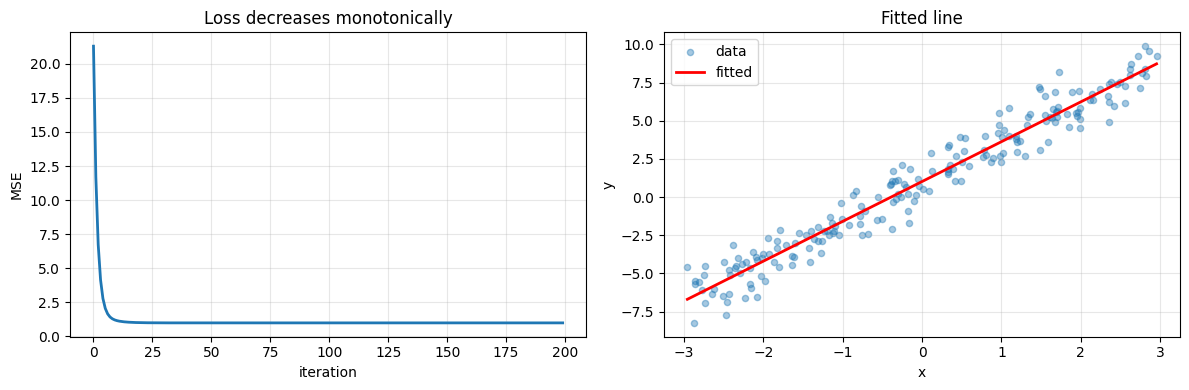

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history, lw=2)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("MSE")
axes[0].set_title("Loss decreases monotonically"); axes[0].grid(alpha=0.3)

xs = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
axes[1].scatter(X, y, alpha=0.4, s=20, label="data")
axes[1].plot(xs, add_bias(xs) @ theta_gd, "r-", lw=2, label="fitted")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Fitted line"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## The learning rate is not a detail

Too small and you never arrive. Too large and the updates overshoot the minimum,
bounce to the other side further out, and the loss diverges to infinity.

There is no universally correct value. There is a range that works for your data,
and finding it is part of the job.

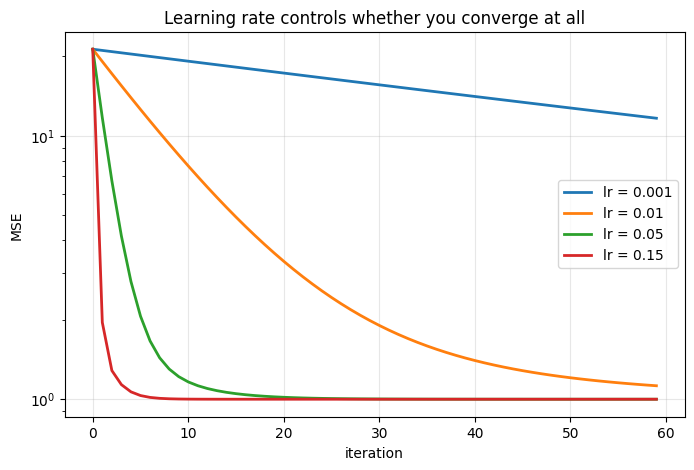

lr = 0.5 losses: [    21.296     67.035    228.712    786.205   2708.544   9337.129
  32193.731 111007.571]
-> exploding, not converging


In [7]:
plt.figure(figsize=(8, 5))

for lr in [0.001, 0.01, 0.05, 0.15]:
    _, hist = fit_gradient_descent(X, y, lr=lr, n_iters=60)
    plt.plot(hist, label=f"lr = {lr}", lw=2)

plt.xlabel("iteration"); plt.ylabel("MSE"); plt.yscale("log")
plt.title("Learning rate controls whether you converge at all")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# And what divergence looks like:
_, diverged = fit_gradient_descent(X, y, lr=0.5, n_iters=20)
print("lr = 0.5 losses:", np.array(diverged[:8]))
print("-> exploding, not converging")

## Evaluate honestly

MSE is in squared target units, which makes it hard to interpret. $R^2$ answers a
better question: what fraction of the variance in `y` does the model explain?

$$R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}$$

$R^2 = 0$ means you did no better than predicting the mean. $R^2 = 1$ is perfect.

In [8]:
from mlscratch.metrics import r2_score
from mlscratch.utils import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, seed=0)

theta_train, _ = fit_gradient_descent(X_train, y_train, lr=0.05, n_iters=500)
train_pred = add_bias(X_train) @ theta_train
test_pred  = add_bias(X_test)  @ theta_train

print(f"train R2: {r2_score(y_train, train_pred):.4f}")
print(f"test  R2: {r2_score(y_test,  test_pred):.4f}")
print("\nNote the ceiling: we added noise with std 1.0, so no model can reach R2 = 1.")

train R2: 0.9551
test  R2: 0.9240

Note the ceiling: we added noise with std 1.0, so no model can reach R2 = 1.


## Exercises

1. **Multiple features.** Regenerate `X` with `n_features=5` and a 5-element
   `true_w`. Does anything in `fit_gradient_descent` need to change? (It should not —
   verify that, and understand why.)

2. **Polynomial features.** Fit $y = x^2$ by adding a squared column to `X`.
   Linear regression means linear in the *parameters*, not in the inputs.

3. **Feature scaling.** Multiply one feature by 1000 and refit. Watch convergence
   collapse, then fix it with `mlscratch.utils.standardize` and explain why it helps.

4. **Ridge.** Add an L2 penalty $\lambda\|\theta\|^2$. Derive the new gradient
   and the new closed form $(X^\top X + \lambda I)^{-1}X^\top y$. Do not penalise
   the intercept — why not?

---

**Next:** [02 — Gradient descent in depth](02_gradient_descent.ipynb)